In [0]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

In [0]:
flights_df = spark.read \
.option("header","true") \
.option("inferSchema","true") \
.csv("/Volumes/ey_data/default/n_vol/Flights.csv")

In [0]:
bookings_df = spark.read \
.option("header","true") \
.option("inferSchema","true") \
.csv("/Volumes/ey_data/default/n_vol/bookings.csv")

In [0]:
preferences_df = spark.read \
.option("multiline","true") \
.json("/Volumes/ey_data/default/n_vol/passenger_preferences.json")

In [0]:
flight_booking = flights_df.join(bookings_df,"flight_id")


In [0]:
from pyspark.sql.functions import split, regexp_replace

raw_df = spark.read.text("/Volumes/ey_data/default/n_vol/Flights.csv")

In [0]:
clean_df = raw_df.withColumn(
    "value",
    regexp_replace("value", '"', "")
)
from pyspark.sql.functions import split

split_df = clean_df.select(
    split("value", ",").alias("data")
)
flights_df = split_df.select(
    col("data")[0].alias("flight_id"),
    col("data")[1].alias("airline"),
    col("data")[2].alias("from_city"),
    col("data")[3].alias("to_city"),
    col("data")[4].cast("int").alias("duration"),
    col("data")[5].alias("status")
)
flights_df = flights_df.filter(col("flight_id") != "flight_id")
display(flights_df)


flight_id,airline,from_city,to_city,duration,status
F101,Indigo,Hyderabad,Delhi,140,On Time
F102,Air India,Mumbai,Chennai,120,Delayed
F103,Vistara,Bangalore,Hyderabad,90,On Time
F104,Indigo,Delhi,Mumbai,130,Cancelled
F105,Air India,Chennai,Bangalore,80,On Time
F106,Akasa,Pune,Delhi,150,Delayed
F107,Vistara,Hyderabad,Kolkata,160,On Time
F108,Indigo,Mumbai,Hyderabad,110,On Time
F109,Akasa,Delhi,Chennai,145,Delayed
F110,Air India,Bangalore,Mumbai,95,On Time


In [0]:
from pyspark.sql.functions import split, regexp_replace, col

# Read the file as text
raw_booking = spark.read.text("/Volumes/ey_data/default/n_vol/bookings.csv")

# Remove double quotes
clean_booking = raw_booking.withColumn(
    "value",
    regexp_replace("value", '"', "")
)

# Split each row by comma
split_booking = clean_booking.select(
    split("value", ",").alias("data")
)

# Create proper columns
bookings_df = split_booking.select(
    col("data")[0].alias("booking_id"),
    col("data")[1].alias("flight_id"),
    col("data")[2].alias("passenger_name"),
    col("data")[3].alias("travel_class"),
    col("data")[4].cast("int").alias("ticket_price"),
    col("data")[5].alias("booking_date")
)

# Remove the header row
bookings_df = bookings_df.filter(col("booking_id") != "booking_id")

# Verify
bookings_df.printSchema()
display(bookings_df)

root
 |-- booking_id: string (nullable = true)
 |-- flight_id: string (nullable = true)
 |-- passenger_name: string (nullable = true)
 |-- travel_class: string (nullable = true)
 |-- ticket_price: integer (nullable = true)
 |-- booking_date: string (nullable = true)



booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
flight_booking = flights_df.join(bookings_df, on="flight_id", how="inner")

display(flight_booking)

flight_id,airline,from_city,to_city,duration,status,booking_id,passenger_name,travel_class,ticket_price,booking_date
F101,Indigo,Hyderabad,Delhi,140,On Time,B1001,Rahul Sharma,Economy,8500,2026-06-01
F101,Indigo,Hyderabad,Delhi,140,On Time,B1002,Priya Reddy,Business,22000,2026-06-01
F102,Air India,Mumbai,Chennai,120,Delayed,B1003,Amit Kumar,Economy,9000,2026-06-02
F103,Vistara,Bangalore,Hyderabad,90,On Time,B1004,Sneha Patel,Premium Economy,15000,2026-06-02
F104,Indigo,Delhi,Mumbai,130,Cancelled,B1005,Farhan Ali,Economy,7500,2026-06-03
F105,Air India,Chennai,Bangalore,80,On Time,B1006,Neha Singh,Business,25000,2026-06-03
F106,Akasa,Pune,Delhi,150,Delayed,B1007,Arjun Verma,Economy,10000,2026-06-04
F107,Vistara,Hyderabad,Kolkata,160,On Time,B1008,Meera Nair,Premium Economy,17000,2026-06-04
F108,Indigo,Mumbai,Hyderabad,110,On Time,B1009,Kiran Rao,Economy,9500,2026-06-05
F109,Akasa,Delhi,Chennai,145,Delayed,B1010,Nisha Reddy,Business,28000,2026-06-05


In [0]:
revenue_airline = flight_booking.groupBy("airline") \
.sum("ticket_price") \
.withColumnRenamed("sum(ticket_price)","Revenue")

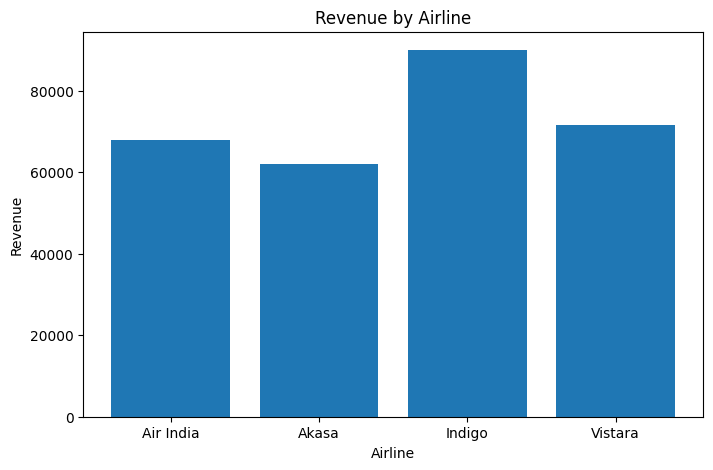

In [0]:
pdf = revenue_airline.toPandas()

plt.figure(figsize=(8,5))

plt.bar(pdf["airline"],pdf["Revenue"])

plt.title("Revenue by Airline")

plt.xlabel("Airline")

plt.ylabel("Revenue")

plt.show()

In [0]:
travel = bookings_df.groupBy("travel_class") \
.sum("ticket_price") \
.withColumnRenamed("sum(ticket_price)","Revenue")

display(travel)

travel_class,Revenue
Business,122000
Premium Economy,81500
Economy,88000


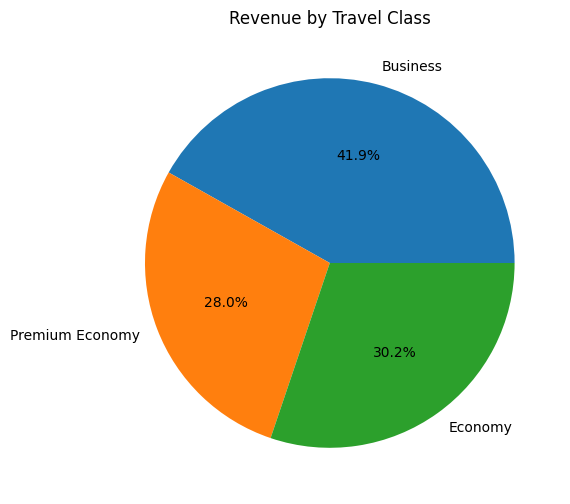

In [0]:
pdf = travel.toPandas()

plt.figure(figsize=(6,6))

plt.pie(
pdf["Revenue"],
labels=pdf["travel_class"],
autopct="%1.1f%%"
)

plt.title("Revenue by Travel Class")

plt.show()

In [0]:
status = flights_df.groupBy("status").count()

display(status)

status,count
On Time,9
Delayed,4
Cancelled,2


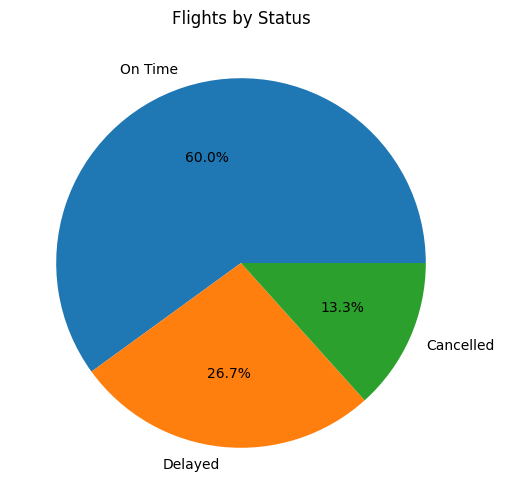

In [0]:
pdf = status.toPandas()

plt.figure(figsize=(6,6))

plt.pie(
pdf["count"],
labels=pdf["status"],
autopct="%1.1f%%"
)

plt.title("Flights by Status")

plt.show()

In [0]:
routes = flight_booking.withColumn(
"Route",
concat_ws(" → ","from_city","to_city")
)

route_revenue = routes.groupBy("Route") \
.sum("ticket_price") \
.withColumnRenamed("sum(ticket_price)","Revenue")

display(route_revenue)

Route,Revenue
Delhi → Chennai,28000
Delhi → Hyderabad,18000
Bangalore → Hyderabad,38000
Kolkata → Bangalore,10500
Hyderabad → Kolkata,26500
Chennai → Pune,24000
Mumbai → Hyderabad,9500
Hyderabad → Goa,16000
Bangalore → Mumbai,23500
Hyderabad → Delhi,39000


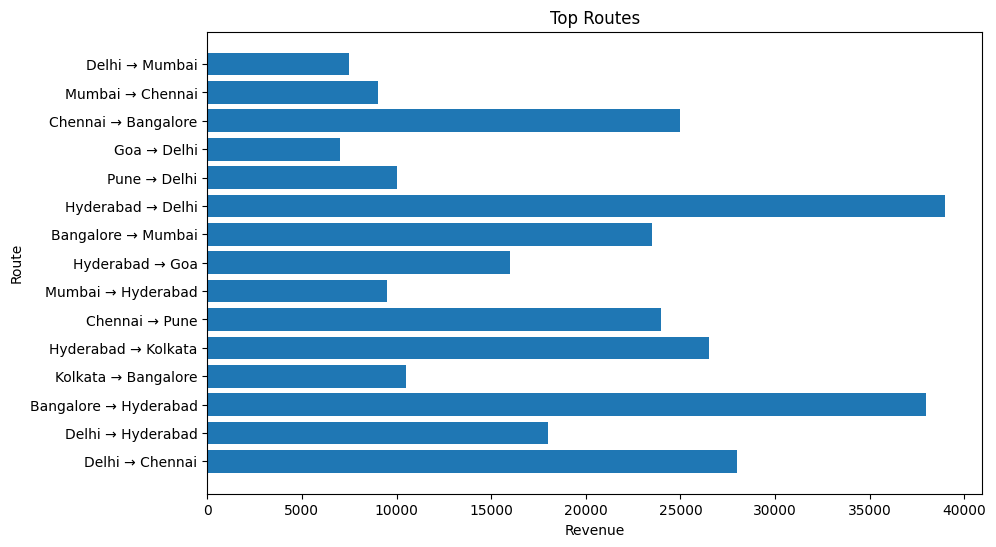

In [0]:
pdf = route_revenue.toPandas()

plt.figure(figsize=(10,6))

plt.barh(pdf["Route"],pdf["Revenue"])

plt.xlabel("Revenue")

plt.ylabel("Route")

plt.title("Top Routes")

plt.show()

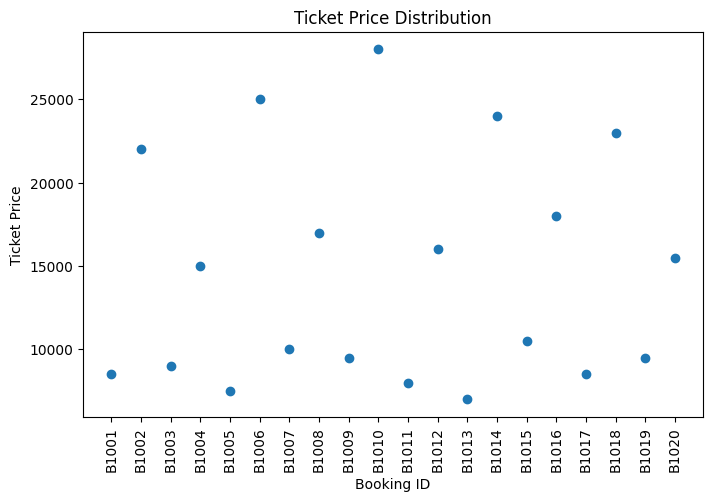

In [0]:
pdf = bookings_df.toPandas()

plt.figure(figsize=(8,5))

plt.scatter(
pdf["booking_id"],
pdf["ticket_price"]
)

plt.xlabel("Booking ID")

plt.ylabel("Ticket Price")

plt.title("Ticket Price Distribution")

plt.xticks(rotation=90)

plt.show()

In [0]:
booking_transformed = bookings_df.withColumn(
"revenue",
col("ticket_price")
)

In [0]:
booking_transformed = booking_transformed.withColumn(
"price_band",
when(col("ticket_price")>20000,"Premium")
.when(col("ticket_price")>10000,"Standard")
.otherwise("Budget")
)

display(booking_transformed)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date,revenue,price_band
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01,8500,Budget
B1002,F101,Priya Reddy,Business,22000,2026-06-01,22000,Premium
B1003,F102,Amit Kumar,Economy,9000,2026-06-02,9000,Budget
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02,15000,Standard
B1005,F104,Farhan Ali,Economy,7500,2026-06-03,7500,Budget
B1006,F105,Neha Singh,Business,25000,2026-06-03,25000,Premium
B1007,F106,Arjun Verma,Economy,10000,2026-06-04,10000,Budget
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04,17000,Standard
B1009,F108,Kiran Rao,Economy,9500,2026-06-05,9500,Budget
B1010,F109,Nisha Reddy,Business,28000,2026-06-05,28000,Premium


In [0]:
flight_transformed = flights_df.withColumn(
"delay_flag",
when(col("status")=="Delayed","Yes")
.otherwise("No")
)

display(flight_transformed)

flight_id,airline,from_city,to_city,duration,status,delay_flag
F101,Indigo,Hyderabad,Delhi,140,On Time,No
F102,Air India,Mumbai,Chennai,120,Delayed,Yes
F103,Vistara,Bangalore,Hyderabad,90,On Time,No
F104,Indigo,Delhi,Mumbai,130,Cancelled,No
F105,Air India,Chennai,Bangalore,80,On Time,No
F106,Akasa,Pune,Delhi,150,Delayed,Yes
F107,Vistara,Hyderabad,Kolkata,160,On Time,No
F108,Indigo,Mumbai,Hyderabad,110,On Time,No
F109,Akasa,Delhi,Chennai,145,Delayed,Yes
F110,Air India,Bangalore,Mumbai,95,On Time,No


In [0]:
journey = flight_transformed.join(
booking_transformed,
"flight_id"
)

In [0]:
journey = journey.join(
preferences_df,
"passenger_name"
)

In [0]:
display(journey)

passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat
Rahul Sharma,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1001,Economy,8500,2026-06-01,8500,Budget,true,Veg,Window
Priya Reddy,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1002,Business,22000,2026-06-01,22000,Premium,false,Non-Veg,Aisle
Amit Kumar,F102,Air India,Mumbai,Chennai,120,Delayed,Yes,B1003,Economy,9000,2026-06-02,9000,Budget,false,Veg,Middle
Sneha Patel,F103,Vistara,Bangalore,Hyderabad,90,On Time,No,B1004,Premium Economy,15000,2026-06-02,15000,Standard,true,Jain,Window
Farhan Ali,F104,Indigo,Delhi,Mumbai,130,Cancelled,No,B1005,Economy,7500,2026-06-03,7500,Budget,false,Non-Veg,Aisle
Neha Singh,F105,Air India,Chennai,Bangalore,80,On Time,No,B1006,Business,25000,2026-06-03,25000,Premium,true,Veg,Window
Arjun Verma,F106,Akasa,Pune,Delhi,150,Delayed,Yes,B1007,Economy,10000,2026-06-04,10000,Budget,false,Veg,Middle
Meera Nair,F107,Vistara,Hyderabad,Kolkata,160,On Time,No,B1008,Premium Economy,17000,2026-06-04,17000,Standard,true,Jain,Window
Kiran Rao,F108,Indigo,Mumbai,Hyderabad,110,On Time,No,B1009,Economy,9500,2026-06-05,9500,Budget,false,Veg,Aisle
Nisha Reddy,F109,Akasa,Delhi,Chennai,145,Delayed,Yes,B1010,Business,28000,2026-06-05,28000,Premium,true,Non-Veg,Window


In [0]:
flights_df.createOrReplaceTempView("flights")

bookings_df.createOrReplaceTempView("bookings")

journey.createOrReplaceTempView("journey")

In [0]:
spark.sql("""
SELECT
    airline,
    SUM(ticket_price) AS Revenue
FROM journey
GROUP BY airline
ORDER BY Revenue DESC
""").show()

+---------+-------+
|  airline|Revenue|
+---------+-------+
|   Indigo|  81500|
|    Akasa|  62000|
|Air India|  52500|
|  Vistara|  39000|
+---------+-------+



In [0]:
route_revenue = spark.sql("""
SELECT
    CONCAT(from_city,' -> ',to_city) AS Route,
    SUM(ticket_price) AS Revenue
FROM journey
GROUP BY from_city,to_city
ORDER BY Revenue DESC
""")

display(route_revenue)

Route,Revenue
Hyderabad -> Delhi,30500
Delhi -> Chennai,28000
Chennai -> Bangalore,25000
Chennai -> Pune,24000
Delhi -> Hyderabad,18000
Hyderabad -> Kolkata,17000
Hyderabad -> Goa,16000
Bangalore -> Hyderabad,15000
Kolkata -> Bangalore,10500
Pune -> Delhi,10000


In [0]:
avg_ticket = spark.sql("""
SELECT
AVG(ticket_price) AS Average_Ticket_Price
FROM bookings
""")

display(avg_ticket)

Average_Ticket_Price
14575.0


In [0]:
popular_destination = spark.sql("""
SELECT
to_city,
COUNT(*) AS Total_Bookings
FROM journey
GROUP BY to_city
ORDER BY Total_Bookings DESC
LIMIT 1
""")

display(popular_destination)

to_city,Total_Bookings
Delhi,4


In [0]:
spark.catalog.listTables()

[Table(name='booking_details', catalog='ey_data', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='booking_master', catalog='ey_data', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='customer_table', catalog='ey_data', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='employees', catalog='ey_data', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='employees_delta', catalog='ey_data', namespace=['default'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='bookings', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='flights', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='journey', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
flight_revenue = journey.groupBy("flight_id", "airline") \
    .agg(sum("ticket_price").alias("Revenue"))

In [0]:
window_spec = Window.orderBy(desc("Revenue"))

In [0]:
top_flights = flight_revenue.withColumn(
    "Rank",
    rank().over(window_spec)
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
display(top_flights.filter(col("Rank") <= 3))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,airline,Revenue,Rank
F101,Indigo,30500,1
F109,Akasa,28000,2
F105,Air India,25000,3


In [0]:
routes = journey.withColumn(
    "Route",
    concat_ws(" -> ", "from_city", "to_city")
)

In [0]:
route_revenue = routes.groupBy(
    "airline",
    "Route"
).agg(
    sum("ticket_price").alias("Revenue")
)

In [0]:
window_route = Window.partitionBy("airline").orderBy(desc("Revenue"))
top_routes = route_revenue.withColumn(
    "Rank",
    rank().over(window_route)
)
display(top_routes)

airline,Route,Revenue,Rank
Air India,Chennai -> Bangalore,25000,1
Air India,Kolkata -> Bangalore,10500,2
Air India,Mumbai -> Chennai,9000,3
Air India,Bangalore -> Mumbai,8000,4
Akasa,Delhi -> Chennai,28000,1
Akasa,Chennai -> Pune,24000,2
Akasa,Pune -> Delhi,10000,3
Indigo,Hyderabad -> Delhi,30500,1
Indigo,Delhi -> Hyderabad,18000,2
Indigo,Hyderabad -> Goa,16000,3


In [0]:
window_running = Window.orderBy("booking_date") \
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
running_revenue = journey.withColumn(
    "Running_Revenue",
    sum("ticket_price").over(window_running)
)
display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat,Running_Revenue
Rahul Sharma,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1001,Economy,8500,2026-06-01,8500,Budget,true,Veg,Window,8500
Priya Reddy,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1002,Business,22000,2026-06-01,22000,Premium,false,Non-Veg,Aisle,30500
Amit Kumar,F102,Air India,Mumbai,Chennai,120,Delayed,Yes,B1003,Economy,9000,2026-06-02,9000,Budget,false,Veg,Middle,39500
Sneha Patel,F103,Vistara,Bangalore,Hyderabad,90,On Time,No,B1004,Premium Economy,15000,2026-06-02,15000,Standard,true,Jain,Window,54500
Farhan Ali,F104,Indigo,Delhi,Mumbai,130,Cancelled,No,B1005,Economy,7500,2026-06-03,7500,Budget,false,Non-Veg,Aisle,62000
Neha Singh,F105,Air India,Chennai,Bangalore,80,On Time,No,B1006,Business,25000,2026-06-03,25000,Premium,true,Veg,Window,87000
Arjun Verma,F106,Akasa,Pune,Delhi,150,Delayed,Yes,B1007,Economy,10000,2026-06-04,10000,Budget,false,Veg,Middle,97000
Meera Nair,F107,Vistara,Hyderabad,Kolkata,160,On Time,No,B1008,Premium Economy,17000,2026-06-04,17000,Standard,true,Jain,Window,114000
Kiran Rao,F108,Indigo,Mumbai,Hyderabad,110,On Time,No,B1009,Economy,9500,2026-06-05,9500,Budget,false,Veg,Aisle,123500
Nisha Reddy,F109,Akasa,Delhi,Chennai,145,Delayed,Yes,B1010,Business,28000,2026-06-05,28000,Premium,true,Non-Veg,Window,151500


In [0]:
airline_revenue = journey.groupBy("airline") \
    .agg(sum("ticket_price").alias("Revenue"))

In [0]:
window_airline = Window.orderBy(desc("Revenue"))
rank_airlines = airline_revenue.withColumn(
    "Rank",
    rank().over(window_airline)
)
display(rank_airlines)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


airline,Revenue,Rank
Indigo,81500,1
Akasa,62000,2
Air India,52500,3
Vistara,39000,4


In [0]:
destination_count = journey.groupBy("to_city") \
    .agg(count("*").alias("Bookings"))

In [0]:
window_destination = Window.orderBy(desc("Bookings"))
dense_rank_destination = destination_count.withColumn(
    "Dense_Rank",
    dense_rank().over(window_destination)
)
display(dense_rank_destination)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


to_city,Bookings,Dense_Rank
Delhi,4,1
Hyderabad,3,2
Chennai,2,3
Bangalore,2,3
Mumbai,2,3
Kolkata,1,4
Pune,1,4
Goa,1,4


In [0]:
journey.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/tmp/booking_master")

In [0]:
journey.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("booking_master")
    

In [0]:
journey.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("booking_master")

In [0]:
spark.sql("SELECT * FROM booking_master").show()

+--------------+---------+---------+---------+---------+--------+---------+----------+----------+---------------+------------+------------+-------+----------+-------------+-------+------+
|passenger_name|flight_id|  airline|from_city|  to_city|duration|   status|delay_flag|booking_id|   travel_class|ticket_price|booking_date|revenue|price_band|extra_baggage|   meal|  seat|
+--------------+---------+---------+---------+---------+--------+---------+----------+----------+---------------+------------+------------+-------+----------+-------------+-------+------+
|  Rahul Sharma|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|     B1001|        Economy|        8500|  2026-06-01|   8500|    Budget|         true|    Veg|Window|
|   Priya Reddy|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|     B1002|       Business|       22000|  2026-06-01|  22000|   Premium|        false|Non-Veg| Aisle|
|    Amit Kumar|     F102|Air India|   Mumbai|  Chennai|    

In [0]:
spark.sql("CREATE DATABASE IF NOT EXISTS airline_db")

DataFrame[]

In [0]:
spark.sql("""
CREATE TABLE IF NOT EXISTS airline_db.booking_details
USING DELTA
AS
SELECT *
FROM booking_master
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
display(spark.sql("""
SELECT *
FROM airline_db.booking_details
"""))

passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat
Rahul Sharma,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1001,Economy,8500,2026-06-01,8500,Budget,true,Veg,Window
Priya Reddy,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1002,Business,22000,2026-06-01,22000,Premium,false,Non-Veg,Aisle
Amit Kumar,F102,Air India,Mumbai,Chennai,120,Delayed,Yes,B1003,Economy,9000,2026-06-02,9000,Budget,false,Veg,Middle
Sneha Patel,F103,Vistara,Bangalore,Hyderabad,90,On Time,No,B1004,Premium Economy,15000,2026-06-02,15000,Standard,true,Jain,Window
Farhan Ali,F104,Indigo,Delhi,Mumbai,130,Cancelled,No,B1005,Economy,7500,2026-06-03,7500,Budget,false,Non-Veg,Aisle
Neha Singh,F105,Air India,Chennai,Bangalore,80,On Time,No,B1006,Business,25000,2026-06-03,25000,Premium,true,Veg,Window
Arjun Verma,F106,Akasa,Pune,Delhi,150,Delayed,Yes,B1007,Economy,10000,2026-06-04,10000,Budget,false,Veg,Middle
Meera Nair,F107,Vistara,Hyderabad,Kolkata,160,On Time,No,B1008,Premium Economy,17000,2026-06-04,17000,Standard,true,Jain,Window
Kiran Rao,F108,Indigo,Mumbai,Hyderabad,110,On Time,No,B1009,Economy,9500,2026-06-05,9500,Budget,false,Veg,Aisle
Nisha Reddy,F109,Akasa,Delhi,Chennai,145,Delayed,Yes,B1010,Business,28000,2026-06-05,28000,Premium,true,Non-Veg,Window


In [0]:
spark.sql("SHOW TABLES").show()

+--------+---------------+-----------+
|database|      tableName|isTemporary|
+--------+---------------+-----------+
| default|booking_details|      false|
| default| booking_master|      false|
| default| customer_table|      false|
| default|      employees|      false|
| default|employees_delta|      false|
|        |       bookings|       true|
|        |        flights|       true|
|        |        journey|       true|
+--------+---------------+-----------+



In [0]:
spark.sql("DESCRIBE booking_master").show(truncate=False)

+--------------+---------+-------+
|col_name      |data_type|comment|
+--------------+---------+-------+
|passenger_name|string   |NULL   |
|flight_id     |string   |NULL   |
|airline       |string   |NULL   |
|from_city     |string   |NULL   |
|to_city       |string   |NULL   |
|duration      |int      |NULL   |
|status        |string   |NULL   |
|delay_flag    |string   |NULL   |
|booking_id    |string   |NULL   |
|travel_class  |string   |NULL   |
|ticket_price  |int      |NULL   |
|booking_date  |string   |NULL   |
|revenue       |int      |NULL   |
|price_band    |string   |NULL   |
|extra_baggage |boolean  |NULL   |
|meal          |string   |NULL   |
|seat          |string   |NULL   |
+--------------+---------+-------+



In [0]:
spark.sql("""
DESCRIBE HISTORY booking_master
""").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                             

In [0]:
spark.sql("""
DESCRIBE DETAIL booking_master
""").show(truncate=False)

+------+------------------------------------+------------------------------+-----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+-------------------+----------------+-----------------+--------+-----------+------------------------------------------------------------------------------+----------------+----------------+-----------------------------------------+---------------------------------------------------------------+-------------+
|format|id                                  |name                          |description|location                                                                                                                                                                                           |createdAt              |lastModified       |partitionColumns|clusteringColumns|numFiles|sizeInByte

In [0]:
bookings_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("booking_master")

In [0]:
from pyspark.sql import Row

day2_data = [
    # NEW BOOKINGS (10)
    Row("B2001","F101","New User1","Economy",9000,"2026-06-02"),
    Row("B2002","F102","New User2","Business",25000,"2026-06-02"),
    Row("B2003","F103","New User3","Economy",7000,"2026-06-02"),
    Row("B2004","F104","New User4","Economy",8000,"2026-06-02"),
    Row("B2005","F105","New User5","Business",30000,"2026-06-02"),
    Row("B2006","F106","New User6","Economy",6500,"2026-06-02"),
    Row("B2007","F107","New User7","Economy",7200,"2026-06-02"),
    Row("B2008","F108","New User8","Business",28000,"2026-06-02"),
    Row("B2009","F109","New User9","Economy",8100,"2026-06-02"),
    Row("B2010","F110","New User10","Economy",6000,"2026-06-02"),

    # PRICE UPDATES (5 existing booking_id)
    Row("B1001","F101","Rahul Sharma","Economy",9500,"2026-06-02"),  # updated
    Row("B1002","F102","Priya Reddy","Business",23000,"2026-06-02"), # updated
    Row("B1003","F103","Amit Kumar","Economy",7800,"2026-06-02"),    # updated
    Row("B1004","F104","Sneha Patel","Economy",8200,"2026-06-02"),   # updated
    Row("B1005","F105","Farhan Ali","Business",31000,"2026-06-02")   # updated
]

In [0]:
day2_df = spark.createDataFrame(day2_data, schema=bookings_df.schema)

In [0]:
day2_df.createOrReplaceTempView("bookings_update")

In [0]:
spark.sql("""
MERGE INTO booking_master AS target
USING bookings_update AS source
ON target.booking_id = source.booking_id

WHEN MATCHED THEN
  UPDATE SET
    target.flight_id = source.flight_id,
    target.passenger_name = source.passenger_name,
    target.travel_class = source.travel_class,
    target.ticket_price = source.ticket_price,
    target.booking_date = source.booking_date

WHEN NOT MATCHED THEN
  INSERT (
    booking_id,
    flight_id,
    passenger_name,
    travel_class,
    ticket_price,
    booking_date
  )
  VALUES (
    source.booking_id,
    source.flight_id,
    source.passenger_name,
    source.travel_class,
    source.ticket_price,
    source.booking_date
  )
""")

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
display(spark.sql("SELECT * FROM booking_master"))

passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat
Neha Singh,F105,null,null,null,null,null,null,B1006,Business,25000,2026-06-03,null,null,null,null,null
Arjun Verma,F106,null,null,null,null,null,null,B1007,Economy,10000,2026-06-04,null,null,null,null,null
Meera Nair,F107,null,null,null,null,null,null,B1008,Premium Economy,17000,2026-06-04,null,null,null,null,null
Kiran Rao,F108,null,null,null,null,null,null,B1009,Economy,9500,2026-06-05,null,null,null,null,null
Nisha Reddy,F109,null,null,null,null,null,null,B1010,Business,28000,2026-06-05,null,null,null,null,null
David Thomas,F110,null,null,null,null,null,null,B1011,Economy,8000,2026-06-06,null,null,null,null,null
Ayesha Khan,F111,null,null,null,null,null,null,B1012,Premium Economy,16000,2026-06-06,null,null,null,null,null
Rohit Sharma,F112,null,null,null,null,null,null,B1013,Economy,7000,2026-06-07,null,null,null,null,null
Pooja Mehta,F113,null,null,null,null,null,null,B1014,Business,24000,2026-06-07,null,null,null,null,null
Sanjay Gupta,F114,null,null,null,null,null,null,B1015,Economy,10500,2026-06-08,null,null,null,null,null


In [0]:
spark.sql("DESCRIBE HISTORY booking_master").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
spark.sql("DESCRIBE HISTORY booking_master").show(truncate=False)


+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
version_0 = spark.read \
    .format("delta") \
    .option("versionAsOf", 0) \
    .table("booking_master")

display(version_0)

passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat
Rahul Sharma,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1001,Economy,8500,2026-06-01,8500,Budget,true,Veg,Window
Priya Reddy,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1002,Business,22000,2026-06-01,22000,Premium,false,Non-Veg,Aisle
Amit Kumar,F102,Air India,Mumbai,Chennai,120,Delayed,Yes,B1003,Economy,9000,2026-06-02,9000,Budget,false,Veg,Middle
Sneha Patel,F103,Vistara,Bangalore,Hyderabad,90,On Time,No,B1004,Premium Economy,15000,2026-06-02,15000,Standard,true,Jain,Window
Farhan Ali,F104,Indigo,Delhi,Mumbai,130,Cancelled,No,B1005,Economy,7500,2026-06-03,7500,Budget,false,Non-Veg,Aisle
Neha Singh,F105,Air India,Chennai,Bangalore,80,On Time,No,B1006,Business,25000,2026-06-03,25000,Premium,true,Veg,Window
Arjun Verma,F106,Akasa,Pune,Delhi,150,Delayed,Yes,B1007,Economy,10000,2026-06-04,10000,Budget,false,Veg,Middle
Meera Nair,F107,Vistara,Hyderabad,Kolkata,160,On Time,No,B1008,Premium Economy,17000,2026-06-04,17000,Standard,true,Jain,Window
Kiran Rao,F108,Indigo,Mumbai,Hyderabad,110,On Time,No,B1009,Economy,9500,2026-06-05,9500,Budget,false,Veg,Aisle
Nisha Reddy,F109,Akasa,Delhi,Chennai,145,Delayed,Yes,B1010,Business,28000,2026-06-05,28000,Premium,true,Non-Veg,Window


In [0]:
version_1 = spark.read \
    .format("delta") \
    .option("versionAsOf", 1) \
    .table("booking_master")

display(version_1)

passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat
Rahul Sharma,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1001,Economy,8500,2026-06-01,8500,Budget,true,Veg,Window
Priya Reddy,F101,Indigo,Hyderabad,Delhi,140,On Time,No,B1002,Business,22000,2026-06-01,22000,Premium,false,Non-Veg,Aisle
Amit Kumar,F102,Air India,Mumbai,Chennai,120,Delayed,Yes,B1003,Economy,9000,2026-06-02,9000,Budget,false,Veg,Middle
Sneha Patel,F103,Vistara,Bangalore,Hyderabad,90,On Time,No,B1004,Premium Economy,15000,2026-06-02,15000,Standard,true,Jain,Window
Farhan Ali,F104,Indigo,Delhi,Mumbai,130,Cancelled,No,B1005,Economy,7500,2026-06-03,7500,Budget,false,Non-Veg,Aisle
Neha Singh,F105,Air India,Chennai,Bangalore,80,On Time,No,B1006,Business,25000,2026-06-03,25000,Premium,true,Veg,Window
Arjun Verma,F106,Akasa,Pune,Delhi,150,Delayed,Yes,B1007,Economy,10000,2026-06-04,10000,Budget,false,Veg,Middle
Meera Nair,F107,Vistara,Hyderabad,Kolkata,160,On Time,No,B1008,Premium Economy,17000,2026-06-04,17000,Standard,true,Jain,Window
Kiran Rao,F108,Indigo,Mumbai,Hyderabad,110,On Time,No,B1009,Economy,9500,2026-06-05,9500,Budget,false,Veg,Aisle
Nisha Reddy,F109,Akasa,Delhi,Chennai,145,Delayed,Yes,B1010,Business,28000,2026-06-05,28000,Premium,true,Non-Veg,Window


In [0]:
latest = spark.read \
    .format("delta") \
    .table("booking_master")

display(latest)

passenger_name,flight_id,airline,from_city,to_city,duration,status,delay_flag,booking_id,travel_class,ticket_price,booking_date,revenue,price_band,extra_baggage,meal,seat
Neha Singh,F105,null,null,null,null,null,null,B1006,Business,25000,2026-06-03,null,null,null,null,null
Arjun Verma,F106,null,null,null,null,null,null,B1007,Economy,10000,2026-06-04,null,null,null,null,null
Meera Nair,F107,null,null,null,null,null,null,B1008,Premium Economy,17000,2026-06-04,null,null,null,null,null
Kiran Rao,F108,null,null,null,null,null,null,B1009,Economy,9500,2026-06-05,null,null,null,null,null
Nisha Reddy,F109,null,null,null,null,null,null,B1010,Business,28000,2026-06-05,null,null,null,null,null
David Thomas,F110,null,null,null,null,null,null,B1011,Economy,8000,2026-06-06,null,null,null,null,null
Ayesha Khan,F111,null,null,null,null,null,null,B1012,Premium Economy,16000,2026-06-06,null,null,null,null,null
Rohit Sharma,F112,null,null,null,null,null,null,B1013,Economy,7000,2026-06-07,null,null,null,null,null
Pooja Mehta,F113,null,null,null,null,null,null,B1014,Business,24000,2026-06-07,null,null,null,null,null
Sanjay Gupta,F114,null,null,null,null,null,null,B1015,Economy,10500,2026-06-08,null,null,null,null,null


In [0]:
display(version_0.select(
    "booking_id",
    "ticket_price"
))

booking_id,ticket_price
B1001,8500
B1002,22000
B1003,9000
B1004,15000
B1005,7500
B1006,25000
B1007,10000
B1008,17000
B1009,9500
B1010,28000


In [0]:
display(version_1.select(
    "booking_id",
    "ticket_price"
))

booking_id,ticket_price
B1001,8500
B1002,22000
B1003,9000
B1004,15000
B1005,7500
B1006,25000
B1007,10000
B1008,17000
B1009,9500
B1010,28000


In [0]:
diff = version_1.alias("v1").join(
    version_0.alias("v0"),
    "booking_id"
).select(
    "booking_id",
    col("v0.ticket_price").alias("old_price"),
    col("v1.ticket_price").alias("new_price")
)

display(diff)

booking_id,old_price,new_price
B1001,8500,8500
B1002,22000,22000
B1003,9000,9000
B1004,15000,15000
B1005,7500,7500
B1006,25000,25000
B1007,10000,10000
B1008,17000,17000
B1009,9500,9500
B1010,28000,28000


In [0]:
spark.sql("OPTIMIZE booking_master")

DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
%sql
OPTIMIZE booking_master
ZORDER BY (flight_id);


path,metrics
abfss://unity-catalog-storage@dbstorage4mxgtbvc3mxyq.dfs.core.windows.net/7405608404634131/__unitystorage/catalogs/65a8445c-1873-4abb-a138-2afe9336535c/tables/d45011ee-67bf-4c27-bc38-5727d0c1ef7b,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 4534), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1781881140095, 1781881140660, 8, 0, null, List(0, 0), null, 17, 17, 0, 0, null, null)"


In [0]:
%sql 
VACUUM booking_master;


path
abfss://unity-catalog-storage@dbstorage4mxgtbvc3mxyq.dfs.core.windows.net/7405608404634131/__unitystorage/catalogs/65a8445c-1873-4abb-a138-2afe9336535c/tables/d45011ee-67bf-4c27-bc38-5727d0c1ef7b


In [0]:
display(spark.sql("DESCRIBE HISTORY booking_master"))

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
7,2026-06-19T14:59:23.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM END,Map(status -> COMPLETED),null,List(4403503708495565),2ec5c487-73fc-41d1-bdd9-2a60a4efa2a5,0619-145048-6jsjpf7v-v2n,6,SnapshotIsolation,true,"Map(numDeletedFiles -> 0, numVacuumedDirectories -> 1)",null,Databricks-Runtime/18.2.x-photon-scala2.13
6,2026-06-19T14:59:22.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM START,"Map(retentionCheckEnabled -> true, defaultRetentionMillis -> 604800000)",null,List(4403503708495565),2ec5c487-73fc-41d1-bdd9-2a60a4efa2a5,0619-145048-6jsjpf7v-v2n,5,SnapshotIsolation,true,"Map(numFilesToDelete -> 0, sizeOfDataToDelete -> 0)",null,Databricks-Runtime/18.2.x-photon-scala2.13
5,2026-06-19T14:56:34.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(4403503708495565),0f1fb04d-19e7-4113-8156-d2c754f82f0e,0619-145048-6jsjpf7v-v2n,4,SnapshotIsolation,false,"Map(numRemovedFiles -> 9, numRemovedBytes -> 33832, p25FileSize -> 4534, numDeletionVectorsRemoved -> 1, minFileSize -> 4534, numAddedFiles -> 1, maxFileSize -> 4534, p75FileSize -> 4534, p50FileSize -> 4534, numAddedBytes -> 4534)",null,Databricks-Runtime/18.2.x-photon-scala2.13
4,2026-06-19T14:56:32.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(booking_id#15345 = booking_id#15313)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(4403503708495565),0f1fb04d-19e7-4113-8156-d2c754f82f0e,0619-145048-6jsjpf7v-v2n,3,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 8, numTargetBytesAdded -> 31242, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 5, executionTimeMs -> 5001, materializeSourceTimeMs -> 219, numTargetRowsInserted -> 10, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 2368, numTargetRowsUpdated -> 5, numOutputRows -> 15, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 15, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2326)",null,Databricks-Runtime/18.2.x-photon-scala2.13
3,2026-06-19T14:55:57.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> false)",null,List(4403503708495565),b5fbbee3-3732-45f9-8a01-989281421f9a,0619-145048-6jsjpf7v-v2n,2,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 5388, numDeletionVectorsRemoved -> 0, numOutputRows -> 20, numOutputBytes -> 2590)",null,Databricks-Runtime/18.2.x-photon-scala2.13
2,2026-06-19T14:52:32.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(4403503708495565),5e33a3ef-025d-4083-9434-312dac2e6655,0619-145048-6jsjpf7v-v2n,1,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 5388, numDeletionVectorsRemoved -> 0, nu

In [0]:
bookings_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("booking_managed")

In [0]:
spark.sql("SELECT * FROM booking_managed").show()

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|
|     B1008|     F107|    Meera Nair|Premium Economy|       17000|  2026-06-04|
|     B1009|     F108|     Kiran Rao|        Economy|        9500|  2026-06-05|
|     B1010|     F109|   Nisha Reddy|   

In [0]:
bookings_df.createOrReplaceTempView("booking_global")

In [0]:
flights_raw = spark.read.csv(
    "/Volumes/ey_data/default/n_vol/Flights.csv",
    header=True,
    inferSchema=True
)


In [0]:
bookings_raw = spark.read.csv(
    "/Volumes/ey_data/default/n_vol/bookings.csv",
    header=True,
    inferSchema=True
)

In [0]:
preferences_raw = spark.read.json(
    "/Volumes/ey_data/default/n_vol/passenger_preferences.json",
    multiLine=True
)

In [0]:
flights_clean = flights_raw.withColumnRenamed("status", "flight_status")

In [0]:
bookings_clean = bookings_raw.withColumn(
    "revenue",
    col("ticket_price")
)

In [0]:
preferences_clean = preferences_raw

In [0]:
gold_df = flights_clean \
    .join(bookings_clean, "flight_id") \
    .join(preferences_clean, "passenger_name")

In [0]:
airline_revenue = gold_df.groupBy("airline") \
    .sum("ticket_price") \
    .withColumnRenamed("sum(ticket_price)", "Revenue")

display(airline_revenue)

In [0]:
route_report = gold_df.withColumn(
    "route",
    concat_ws(" -> ", "from_city", "to_city")
).groupBy("route") \
.sum("ticket_price") \
.withColumnRenamed("sum(ticket_price)", "Revenue")

display(route_report)

In [0]:
passenger_pref = gold_df.select(
    "passenger_name",
    "meal",
    "seat"
)

display(passenger_pref)

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import dense_rank, sum, desc

flight_revenue = gold_df.groupBy("flight_id") \
    .agg(sum("ticket_price").alias("Revenue"))

window_spec = Window.orderBy(desc("Revenue"))

top_flights = flight_revenue.withColumn(
    "Rank",
    dense_rank().over(window_spec)
)

display(top_flights)